         count     mean
Cluster                
0          268  3156.08
1          512  2148.55
2          437  1129.16
         날짜수   평균기온  평균강수량   평균습도    평균이용객
Cluster                                   
0        268  16.36   0.01  49.29  3156.08
1        512  22.28   0.40  77.22  2148.55
2        437   2.47   0.14  61.78  1129.16
day_type   주말   평일  휴일
Cluster               
0          72  191   5
1         151  335  26
2         115  294  28


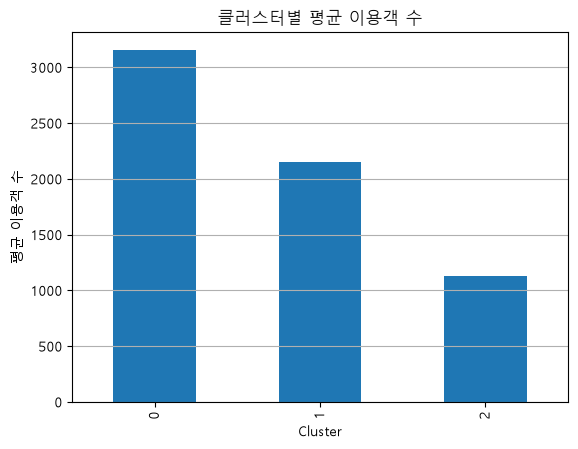

c:\python_proj\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


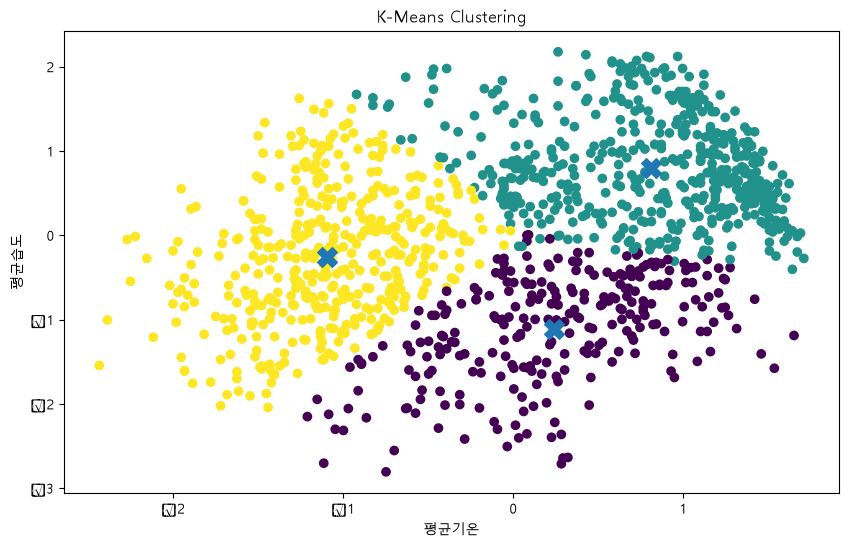

In [ ]:
# 미리보는 결론 : 비지도학습은 구간 분류로 쓰기 어려움-> Oworld_classification 봐주세요
#
# 데이터셋의 이용객수를 제외하고 "휴일","요일","기온","비","습도" 데이터만 가지고 비지도 학습 진행
# 이후 만들어진 클러스터별로 이용객수의 평균을 구하여 매핑 진행.
# 결과는 클러스터별로 이용객 수가 꽤 차이가 많이 나는 것을 확인(0: 3156/ 1:2158 /2: 1129)
# 근데 가장 영향을 많이 줘야 하는 주말/휴일 구분이 거의 차이가 나지 않는 것을 확인
# 군집이 만들어질 때 평일 자체가 주말에 비해 많기 때문에 주말 특성을 잡아먹은 것 같으로 추정



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
df = pd.read_csv("Oworld.csv", encoding="utf-8-sig")
# 한글폰트 설정
plt.rc('font', family = 'Malgun Gothic')

X = df[["holiday","mon","tue","wed","thur","fri","sat","sun","temperature","rain","humidity"]]
# 범주형 데이터 휴일 구분-> 원핫인코딩
#one_hot_encoder = OneHotEncoder(sparse_output=False)
#one_hot_encoded = one_hot_encoder.fit_transform(df[["휴일구분"]])
#one_hot_columns = one_hot_encoder.get_feature_names_out(["휴일구분"])
#one_hot_df = pd.DataFrame(
#    one_hot_encoded,
#    columns=one_hot_columns,
#    index=df.index
#)

# 평균기온, 일강수량, 평균상대습도
numeric_features = ["temperature", "humidity"]

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df[numeric_features])

numeric_df = pd.DataFrame(
    numeric_scaled,
    columns=numeric_features,
    index=df.index
)

# 이진 데이터
binary_features = [
    "holiday",
    "mon",
    "tue",
    "wed",
    "thur",
    "fri",
    "sat",
    "sun",
    "rain"
]
binary_df = df[binary_features]

# 합치기
X_processed = pd.concat([numeric_df, binary_df],axis=1)

# kmeans 비지도 학습
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
)
cluster_labels = kmeans.fit_predict(X_processed)

df["Cluster"] = cluster_labels

# 클러스터별 이용객수
cluster_ = (
    df.groupby("Cluster")["visitors"]
    .agg(
        count="count",
        mean="mean"
    )
    .round(2)
)

print(cluster_)

#클러스터별 전체 결과
cluster_summary = (
    df.groupby("Cluster")
    .agg(
        날짜수=("visitors", "count"),
        평균기온=("temperature", "mean"),
        평균강수량=("rain", "mean"),
        평균습도=("humidity", "mean"),
        평균이용객=("visitors", "mean"),
    )
    .round(2)
)
print(cluster_summary)


#클러스터별 요일 분포 확인
def classify_day(row):
    if row["holiday"] == 1:
        return "휴일"
    elif row["sat"] == 1 or row["sun"] == 1:
        return "주말"
    else:
        return "평일"

df["day_type"] = df.apply(classify_day, axis=1)

cluster_day = pd.crosstab(
    df["Cluster"],
    df["day_type"]
)

print(cluster_day)

# 클러스터별 평균 이용객수
cluster_summary["평균이용객"].plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("평균 이용객 수")
plt.title("클러스터별 평균 이용객 수")

plt.grid(axis="y")
plt.show()

# 군집 시각화
plt.figure(figsize=(10, 6))

plt.scatter(
    numeric_scaled[:, 0],
    numeric_scaled[:, 1],
    c=cluster_labels,
    cmap="viridis"
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)
plt.xlabel("평균기온")
plt.ylabel("평균습도")
plt.title("K-Means Clustering")

plt.show()

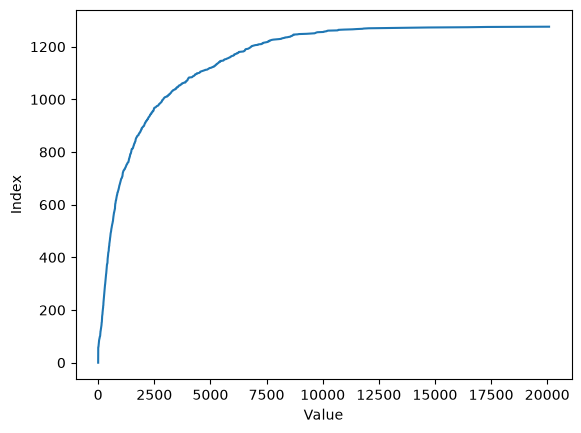

In [15]:
df_sorted = df.sort_values("전체건수").reset_index(drop=True)

plt.plot(df_sorted["전체건수"], df_sorted.index)
plt.xlabel("Value")
plt.ylabel("Index")
plt.show()